# LightGBM & XGBoost — Titanic Survival Prediction
**Objective:** Compare the performance of LightGBM and XGBoost algorithms on the Titanic dataset for binary classification (Survived vs Not Survived).

**Datasets:** `Titanic_train.csv` (891 rows) · `Titanic_test.csv` (418 rows)

---
## 0. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Gradient boosting libraries
import lightgbm as lgb
import xgboost  as xgb

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.preprocessing  import LabelEncoder, StandardScaler
from sklearn.metrics         import (accuracy_score, precision_score,
                                     recall_score, f1_score,
                                     roc_auc_score, roc_curve,
                                     confusion_matrix, classification_report)

plt.style.use('seaborn-v0_8-whitegrid')
SURV_PAL = {0: 'tomato', 1: 'steelblue'}

print(f'LightGBM : {lgb.__version__}')
print(f'XGBoost  : {xgb.__version__}')
print('All libraries loaded.')

LightGBM : 4.6.0
XGBoost  : 3.2.0
All libraries loaded.


---
## Part 1 — Exploratory Data Analysis (EDA)

In [2]:
# Load both datasets — same filenames as provided
train_raw = pd.read_csv('Titanic_train.csv')
test_raw  = pd.read_csv('Titanic_test.csv')

print('Train shape:', train_raw.shape)
print('Test  shape:', test_raw.shape)
train_raw.head()

Train shape: (891, 12)
Test  shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Data types and column overview
print('Column Data Types:')
print(train_raw.dtypes)
print()
train_raw.describe(include='all')

Column Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [4]:
# Missing value analysis — Train & Test
def missing_report(df, name):
    m   = df.isnull().sum()
    pct = (m / len(df) * 100).round(2)
    r   = pd.DataFrame({'Count': m, 'Percent(%)': pct})
    r   = r[r['Count'] > 0].sort_values('Count', ascending=False)
    print(f'{name}:')
    print(r.to_string() if len(r) else '  None')
    print()

missing_report(train_raw, 'Train Missing Values')
missing_report(test_raw,  'Test Missing Values')

Train Missing Values:
          Count  Percent(%)
Cabin       687       77.10
Age         177       19.87
Embarked      2        0.22

Test Missing Values:
       Count  Percent(%)
Cabin    327       78.23
Age       86       20.57
Fare       1        0.24



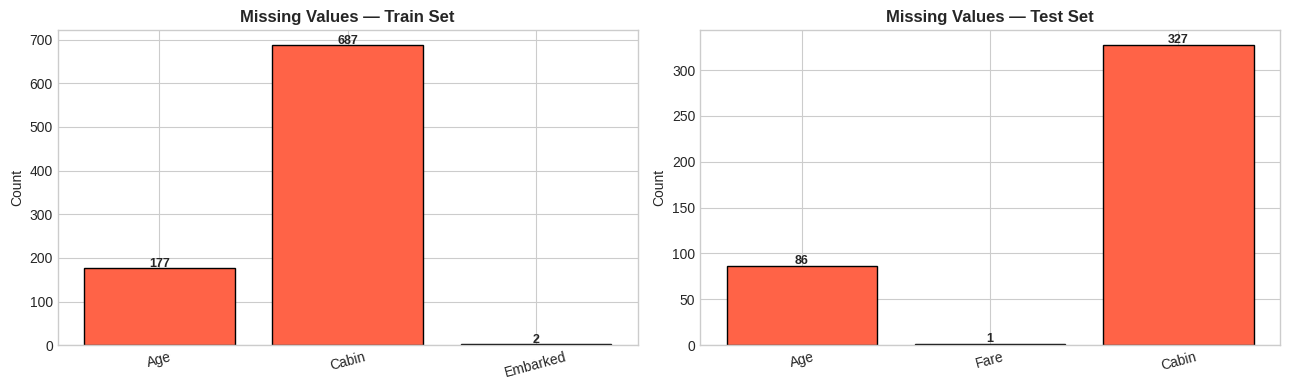

In [5]:
# Missing value bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, df, title in zip(axes,
                          [train_raw, test_raw],
                          ['Train', 'Test']):
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    ax.bar(miss.index, miss.values, color='tomato', edgecolor='black')
    for i, v in enumerate(miss.values):
        ax.text(i, v + 2, str(v), ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'Missing Values — {title} Set', fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

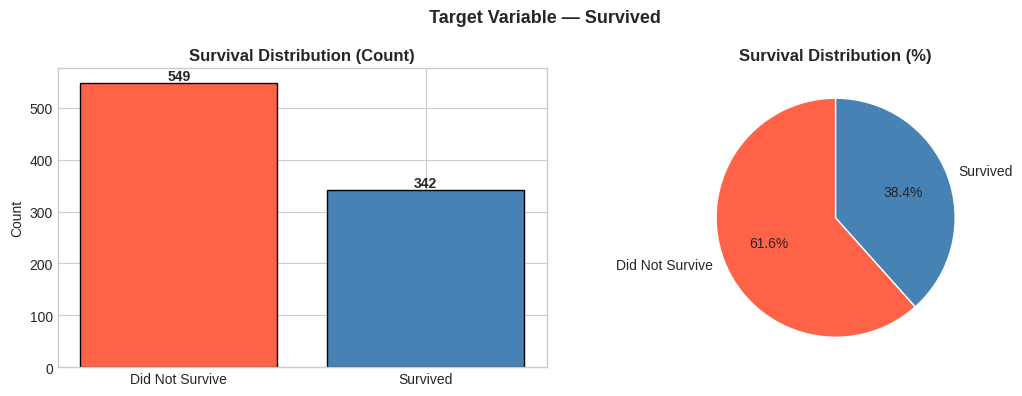

In [6]:
# Target class distribution
surv_counts = train_raw['Survived'].value_counts()
labels      = ['Did Not Survive', 'Survived']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
bars = axes[0].bar(labels,
                   [surv_counts[0], surv_counts[1]],
                   color=['tomato', 'steelblue'], edgecolor='black')
for bar, v in zip(bars, [surv_counts[0], surv_counts[1]]):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+5, str(v),
                 ha='center', fontweight='bold')
axes[0].set_title('Survival Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie([surv_counts[0], surv_counts[1]],
            labels=labels, colors=['tomato','steelblue'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Survival Distribution (%)', fontweight='bold')

plt.suptitle('Target Variable — Survived', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

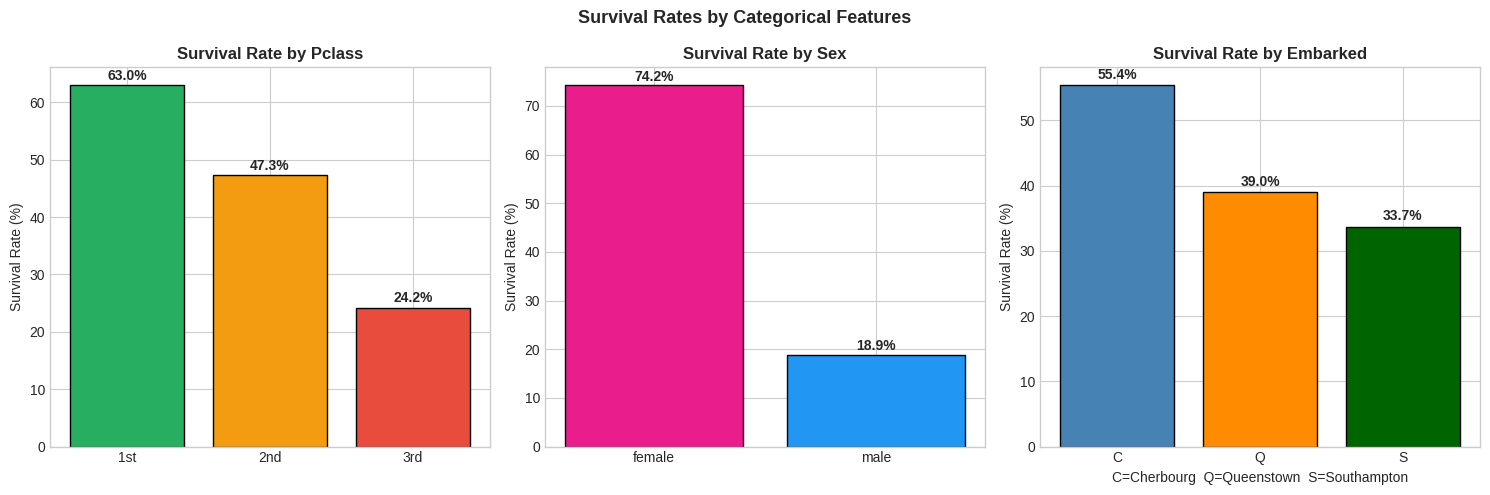

In [7]:
# Survival rate by key categorical features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# By Pclass
pc = train_raw.groupby('Pclass')['Survived'].mean() * 100
axes[0].bar(['1st','2nd','3rd'], pc.values,
            color=['#27ae60','#f39c12','#e74c3c'], edgecolor='black')
for i, v in enumerate(pc.values):
    axes[0].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Survival Rate by Pclass', fontweight='bold')
axes[0].set_ylabel('Survival Rate (%)')

# By Sex
sx = train_raw.groupby('Sex')['Survived'].mean() * 100
axes[1].bar(sx.index, sx.values,
            color=['#e91e8c','#2196f3'], edgecolor='black')
for i, v in enumerate(sx.values):
    axes[1].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Survival Rate by Sex', fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')

# By Embarked
em = train_raw.groupby('Embarked')['Survived'].mean() * 100
axes[2].bar(em.index, em.values,
            color=['steelblue','darkorange','darkgreen'], edgecolor='black')
for i, v in enumerate(em.values):
    axes[2].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
axes[2].set_title('Survival Rate by Embarked', fontweight='bold')
axes[2].set_ylabel('Survival Rate (%)')
axes[2].set_xlabel('C=Cherbourg  Q=Queenstown  S=Southampton')

plt.suptitle('Survival Rates by Categorical Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

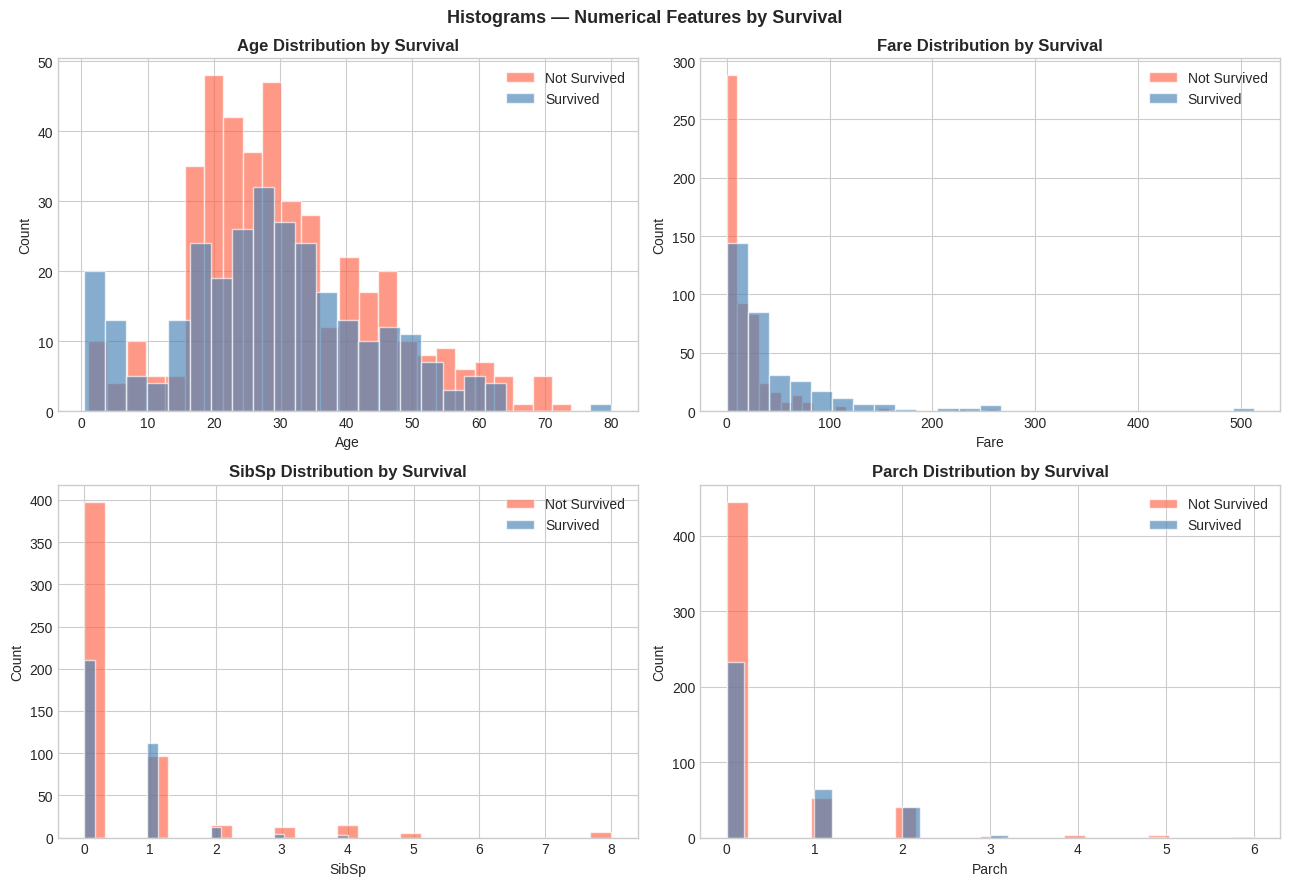

In [8]:
# Histograms — numerical features by survival
num_feats = ['Age', 'Fare', 'SibSp', 'Parch']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, col in enumerate(num_feats):
    for s_val, color in SURV_PAL.items():
        data = train_raw[train_raw['Survived']==s_val][col].dropna()
        axes[i].hist(data, bins=25, alpha=0.65, color=color,
                     edgecolor='white',
                     label='Not Survived' if s_val==0 else 'Survived')
    axes[i].set_title(f'{col} Distribution by Survival', fontweight='bold')
    axes[i].set_xlabel(col); axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Histograms — Numerical Features by Survival',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

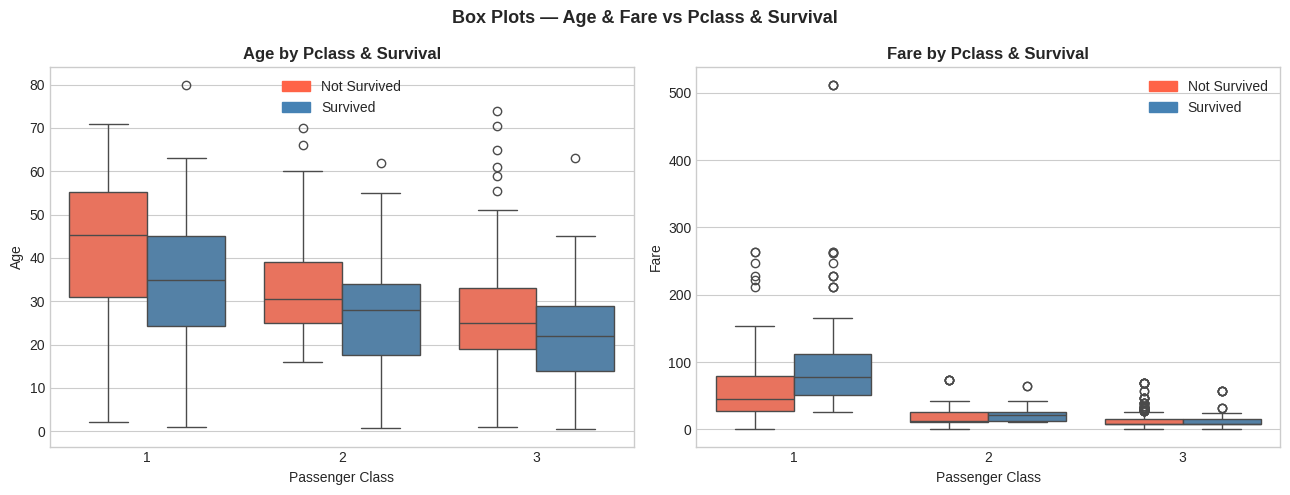

In [9]:
# Box plots — Age and Fare by Pclass and Survival
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=train_raw, x='Pclass', y='Age',
            hue='Survived', ax=axes[0],
            palette=SURV_PAL)
axes[0].set_title('Age by Pclass & Survival', fontweight='bold')
axes[0].set_xlabel('Passenger Class')
handles = [mpatches.Patch(color='tomato', label='Not Survived'),
           mpatches.Patch(color='steelblue', label='Survived')]
axes[0].legend(handles=handles)

sns.boxplot(data=train_raw, x='Pclass', y='Fare',
            hue='Survived', ax=axes[1],
            palette=SURV_PAL)
axes[1].set_title('Fare by Pclass & Survival', fontweight='bold')
axes[1].set_xlabel('Passenger Class')
axes[1].legend(handles=handles)

plt.suptitle('Box Plots — Age & Fare vs Pclass & Survival',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

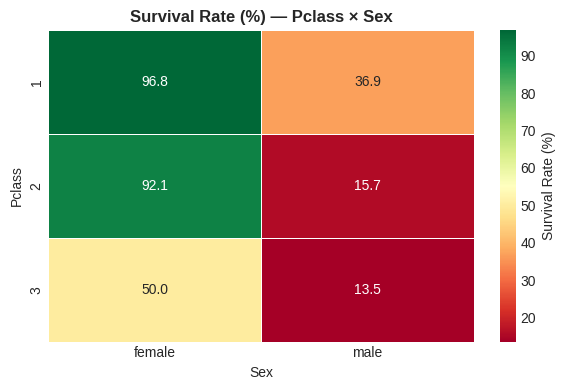

In [10]:
# Pclass × Sex survival heatmap
pivot = train_raw.pivot_table(
    values='Survived', index='Pclass',
    columns='Sex', aggfunc='mean'
) * 100

plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'label': 'Survival Rate (%)'})
plt.title('Survival Rate (%) — Pclass × Sex', fontweight='bold')
plt.tight_layout()
plt.show()

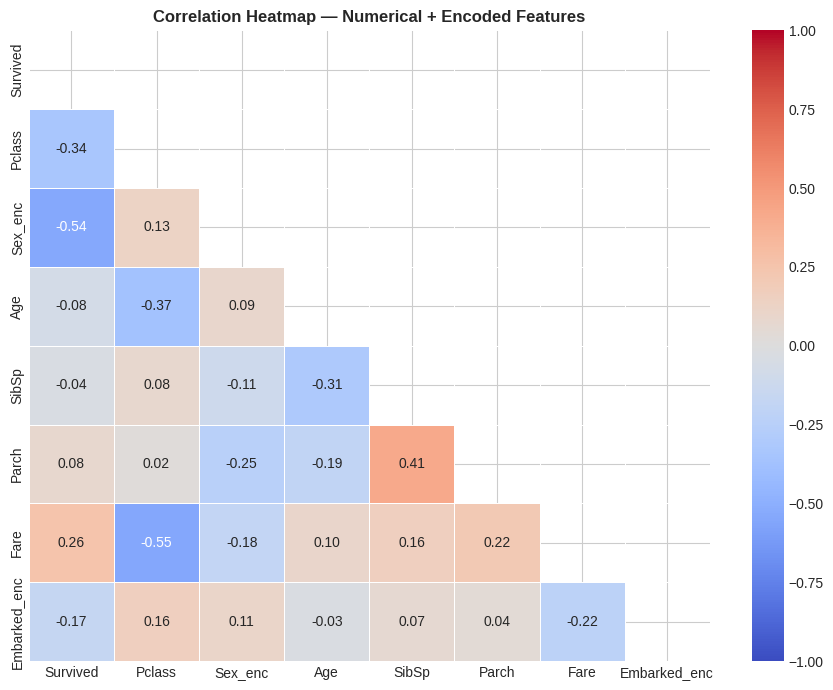

In [11]:
# Correlation heatmap (encoded)
df_corr = train_raw.copy()
df_corr['Sex_enc']      = (df_corr['Sex']=='male').astype(int)
df_corr['Embarked_enc'] = LabelEncoder().fit_transform(
    df_corr['Embarked'].fillna('S'))
num_corr_cols = ['Survived','Pclass','Sex_enc','Age',
                 'SibSp','Parch','Fare','Embarked_enc']
corr = df_corr[num_corr_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5,
            vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Numerical + Encoded Features',
          fontweight='bold')
plt.tight_layout()
plt.show()

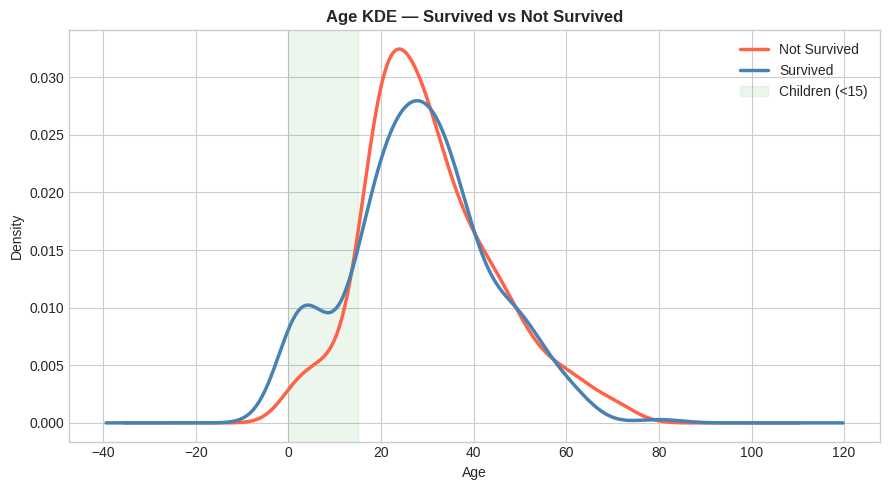

In [12]:
# Age distribution — KDE by survival
plt.figure(figsize=(9, 5))
for s_val, color, label in zip([0,1],
                                ['tomato','steelblue'],
                                ['Not Survived','Survived']):
    train_raw[train_raw['Survived']==s_val]['Age'].dropna()\
        .plot(kind='kde', color=color, lw=2.5, label=label)
plt.axvspan(0, 15, alpha=0.07, color='green', label='Children (<15)')
plt.title('Age KDE — Survived vs Not Survived', fontweight='bold')
plt.xlabel('Age'); plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

---
## Part 2 — Data Preprocessing

In [13]:
# Combine train + test for consistent preprocessing
test_raw['Survived'] = np.nan
combined = pd.concat([train_raw, test_raw], ignore_index=True)
print('Combined shape:', combined.shape)

Combined shape: (1309, 12)


In [14]:
# ── Feature Engineering ──────────────────────────────────────────

# 1. Title from Name
combined['Title'] = combined['Name'].str.extract(r' ([A-Za-z]+)\.',
                                                   expand=False)
title_map = {'Mr':'Mr','Miss':'Miss','Mrs':'Mrs','Master':'Master',
             'Dr':'Rare','Rev':'Rare','Col':'Rare','Major':'Rare',
             'Mlle':'Miss','Countess':'Rare','Ms':'Miss',
             'Lady':'Rare','Jonkheer':'Rare','Don':'Rare',
             'Dona':'Rare','Mme':'Mrs','Capt':'Rare','Sir':'Rare'}
combined['Title'] = combined['Title'].map(title_map).fillna('Rare')
print('Title distribution:')
print(combined['Title'].value_counts().to_string())

Title distribution:
Title
Mr        757
Miss      264
Mrs       198
Master     61
Rare       29


In [15]:
# 2. Family features
combined['FamilySize'] = combined['SibSp'] + combined['Parch'] + 1
combined['IsAlone']    = (combined['FamilySize'] == 1).astype(int)

# 3. Cabin flag
combined['HasCabin']   = combined['Cabin'].notnull().astype(int)

# 4. Age bins
combined['AgeBin'] = pd.cut(
    combined['Age'], bins=[0,12,18,35,60,100],
    labels=[0,1,2,3,4]
)

# 5. Fare log transform (handle skew)
combined['LogFare'] = np.log1p(combined['Fare'])

print('New features: FamilySize, IsAlone, HasCabin, AgeBin, LogFare')

New features: FamilySize, IsAlone, HasCabin, AgeBin, LogFare


In [16]:
# ── Handle Missing Values ─────────────────────────────────────────

# Age — group median by Pclass + Title
combined['Age'] = combined.groupby(['Pclass','Title'])['Age']\
                           .transform(lambda x: x.fillna(x.median()))
combined['Age'].fillna(combined['Age'].median(), inplace=True)

# Fare — Pclass median
combined['Fare'] = combined.groupby('Pclass')['Fare']\
                            .transform(lambda x: x.fillna(x.median()))

# Embarked — mode
combined['Embarked'].fillna(combined['Embarked'].mode()[0], inplace=True)

# AgeBin — refill after Age imputation
combined['AgeBin'] = pd.cut(
    combined['Age'], bins=[0,12,18,35,60,100],
    labels=[0,1,2,3,4]
).astype(float)

# LogFare update
combined['LogFare'] = np.log1p(combined['Fare'])

print('Remaining nulls (features):')
feat_cols = ['Age','Fare','Embarked','AgeBin','LogFare']
print(combined[feat_cols].isnull().sum().to_string())

Remaining nulls (features):
Age         0
Fare        0
Embarked    2
AgeBin      0
LogFare     0


In [17]:
# ── Encode Categorical Variables ──────────────────────────────────

# Binary encode Sex
combined['Sex'] = (combined['Sex'] == 'male').astype(int)

# One-Hot Encode Embarked
emb_dummies = pd.get_dummies(combined['Embarked'],
                              prefix='Emb', drop_first=False)
combined    = pd.concat([combined, emb_dummies], axis=1)

# Label Encode Title
le_title = LabelEncoder()
combined['Title_enc'] = le_title.fit_transform(combined['Title'])
print('Title encoding:', dict(zip(le_title.classes_,
                                   le_title.transform(le_title.classes_))))

# Convert bool OHE to int
bool_cols = combined.select_dtypes(include='bool').columns
combined[bool_cols] = combined[bool_cols].astype(int)

print('\nEncoding complete.')

Title encoding: {'Master': np.int64(0), 'Miss': np.int64(1), 'Mr': np.int64(2), 'Mrs': np.int64(3), 'Rare': np.int64(4)}

Encoding complete.


In [18]:
# ── Final Feature Set ─────────────────────────────────────────────
FEATURES = ['Pclass','Sex','Age','LogFare','FamilySize','IsAlone',
            'HasCabin','Title_enc','AgeBin','SibSp','Parch',
            'Emb_C','Emb_Q','Emb_S']

# Split back to train/test
train_proc = combined[combined['Survived'].notna()].copy()
test_proc  = combined[combined['Survived'].isna()].copy()

X_all  = train_proc[FEATURES].astype(float)
y_all  = train_proc['Survived'].astype(int)
X_kaggle = test_proc[FEATURES].astype(float)

print(f'X_all shape   : {X_all.shape}')
print(f'X_kaggle shape: {X_kaggle.shape}')
print(f'Features used : {FEATURES}')

X_all shape   : (891, 14)
X_kaggle shape: (418, 14)
Features used : ['Pclass', 'Sex', 'Age', 'LogFare', 'FamilySize', 'IsAlone', 'HasCabin', 'Title_enc', 'AgeBin', 'SibSp', 'Parch', 'Emb_C', 'Emb_Q', 'Emb_S']


In [19]:
# Train / Validation split — 80/20 stratified
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)
print(f'Train : {len(X_train)} samples')
print(f'Val   : {len(X_val)}   samples')

Train : 712 samples
Val   : 179   samples


---
## Part 3 — Building Predictive Models

### 3a. Evaluation Helper

In [20]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Fit model, evaluate on val set, run 5-fold CV."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        y_prob = model.decision_function(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv  = cross_val_score(model, X_tr, y_tr,
                          cv=skf, scoring='accuracy').mean()

    print(f'=== {name} ===')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(f'  5-Fold CV : {cv:.4f}')
    print()
    return {'Model':name, 'Accuracy':acc, 'Precision':prec,
            'Recall':rec, 'F1':f1, 'ROC_AUC':auc,
            'CV_Acc':cv, 'y_pred':y_pred, 'y_prob':y_prob}

print('Evaluation helper ready.')

Evaluation helper ready.


### 3b. Baseline LightGBM

In [21]:
lgbm_base = lgb.LGBMClassifier(
    n_estimators   = 300,
    learning_rate  = 0.05,
    max_depth      = 6,
    num_leaves     = 31,
    subsample      = 0.8,
    colsample_bytree=0.8,
    random_state   = 42,
    verbose        = -1
)
res_lgbm_base = evaluate_model(
    'LightGBM (Baseline)',
    lgbm_base, X_train, y_train, X_val, y_val
)

=== LightGBM (Baseline) ===
  Accuracy  : 0.7877
  Precision : 0.7460
  Recall    : 0.6812
  F1-Score  : 0.7121
  ROC-AUC   : 0.8146
  5-Fold CV : 0.8189



### 3c. Baseline XGBoost

In [22]:
xgbm_base = xgb.XGBClassifier(
    n_estimators   = 300,
    learning_rate  = 0.05,
    max_depth      = 6,
    subsample      = 0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric    = 'logloss',
    random_state   = 42,
    verbosity      = 0
)
res_xgbm_base = evaluate_model(
    'XGBoost (Baseline)',
    xgbm_base, X_train, y_train, X_val, y_val
)

=== XGBoost (Baseline) ===
  Accuracy  : 0.7877
  Precision : 0.7460
  Recall    : 0.6812
  F1-Score  : 0.7121
  ROC-AUC   : 0.8267
  5-Fold CV : 0.8175



### 3d. Hyperparameter Tuning — LightGBM

In [23]:
# GridSearchCV for LightGBM
lgbm_param_grid = {
    'n_estimators'    : [200, 400],
    'learning_rate'   : [0.05, 0.1],
    'max_depth'       : [4, 6],
    'num_leaves'      : [15, 31],
    'subsample'       : [0.8],
    'colsample_bytree': [0.8]
}

lgbm_grid = GridSearchCV(
    lgb.LGBMClassifier(random_state=42, verbose=-1),
    lgbm_param_grid,
    cv=5, scoring='accuracy',
    n_jobs=-1, verbose=1
)
lgbm_grid.fit(X_train, y_train)

print(f'\nLightGBM best params : {lgbm_grid.best_params_}')
print(f'Best CV Accuracy     : {lgbm_grid.best_score_:.4f}')

Fitting 5 folds for each of 16 candidates, totalling 80 fits



LightGBM best params : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 400, 'num_leaves': 15, 'subsample': 0.8}
Best CV Accuracy     : 0.8260


In [24]:
# Evaluate tuned LightGBM
res_lgbm_tuned = evaluate_model(
    'LightGBM (Tuned)',
    lgbm_grid.best_estimator_,
    X_train, y_train, X_val, y_val
)

=== LightGBM (Tuned) ===
  Accuracy  : 0.7877
  Precision : 0.7460
  Recall    : 0.6812
  F1-Score  : 0.7121
  ROC-AUC   : 0.8335
  5-Fold CV : 0.8301



### 3e. Hyperparameter Tuning — XGBoost

In [25]:
# GridSearchCV for XGBoost
xgbm_param_grid = {
    'n_estimators'    : [200, 400],
    'learning_rate'   : [0.05, 0.1],
    'max_depth'       : [4, 6],
    'subsample'       : [0.8],
    'colsample_bytree': [0.8]
}

xgbm_grid = GridSearchCV(
    xgb.XGBClassifier(use_label_encoder=False,
                       eval_metric='logloss',
                       random_state=42, verbosity=0),
    xgbm_param_grid,
    cv=5, scoring='accuracy',
    n_jobs=-1, verbose=1
)
xgbm_grid.fit(X_train, y_train)

print(f'\nXGBoost best params  : {xgbm_grid.best_params_}')
print(f'Best CV Accuracy     : {xgbm_grid.best_score_:.4f}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits



XGBoost best params  : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 400, 'subsample': 0.8}
Best CV Accuracy     : 0.8147


In [26]:
# Evaluate tuned XGBoost
res_xgbm_tuned = evaluate_model(
    'XGBoost (Tuned)',
    xgbm_grid.best_estimator_,
    X_train, y_train, X_val, y_val
)

=== XGBoost (Tuned) ===
  Accuracy  : 0.7877
  Precision : 0.7460
  Recall    : 0.6812
  F1-Score  : 0.7121
  ROC-AUC   : 0.8307
  5-Fold CV : 0.8287



In [27]:
# Classification reports — Tuned models
for res, name in [(res_lgbm_tuned,'LightGBM Tuned'),
                   (res_xgbm_tuned,'XGBoost Tuned')]:
    print(f'Classification Report — {name}:')
    print(classification_report(y_val, res['y_pred'],
                                 target_names=['Not Survived','Survived']))
    print()

Classification Report — LightGBM Tuned:
              precision    recall  f1-score   support

Not Survived       0.81      0.85      0.83       110
    Survived       0.75      0.68      0.71        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179


Classification Report — XGBoost Tuned:
              precision    recall  f1-score   support

Not Survived       0.81      0.85      0.83       110
    Survived       0.75      0.68      0.71        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179




---
## Part 4 — Comparative Analysis & Visualization

In [28]:
# Full comparison table
all_results = [res_lgbm_base, res_xgbm_base,
               res_lgbm_tuned, res_xgbm_tuned]

comp_df = pd.DataFrame([
    {k:v for k,v in r.items()
     if k not in ['y_pred','y_prob']}
    for r in all_results
]).round(4)

print('Model Performance Comparison:')
comp_df

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,CV_Acc
0,LightGBM (Baseline),0.7877,0.746,0.6812,0.7121,0.8146,0.8189
1,XGBoost (Baseline),0.7877,0.746,0.6812,0.7121,0.8267,0.8175
2,LightGBM (Tuned),0.7877,0.746,0.6812,0.7121,0.8335,0.8301
3,XGBoost (Tuned),0.7877,0.746,0.6812,0.7121,0.8307,0.8287


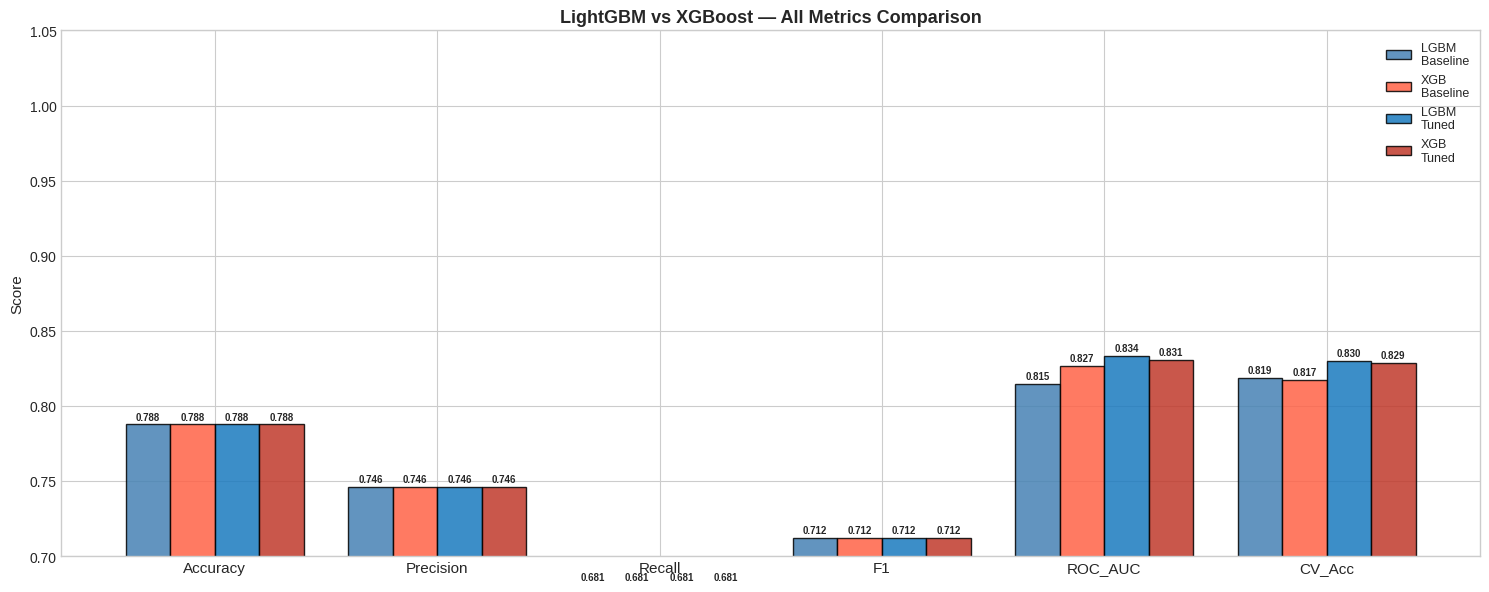

In [29]:
# Grouped bar chart — all metrics
metrics    = ['Accuracy','Precision','Recall','F1','ROC_AUC','CV_Acc']
model_cols = ['steelblue','tomato','#1a7abf','#c0392b']
short_names = ['LGBM\nBaseline','XGB\nBaseline',
               'LGBM\nTuned','XGB\nTuned']

x = np.arange(len(metrics)); w = 0.20
fig, ax = plt.subplots(figsize=(15, 6))

for i, (res, color, sname) in enumerate(
    zip(all_results, model_cols, short_names)
):
    vals = [res[m] for m in metrics]
    bars = ax.bar(x + i*w, vals, w, label=sname,
                  color=color, edgecolor='black', alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.003,
                f'{v:.3f}', ha='center',
                fontsize=7, fontweight='bold')

ax.set_xticks(x + w*1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.7, 1.05)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('LightGBM vs XGBoost — All Metrics Comparison',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

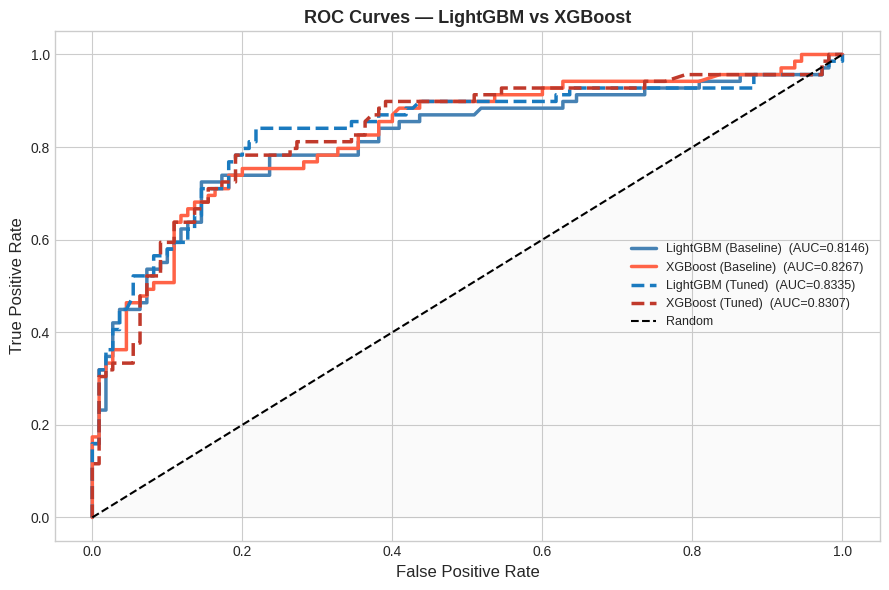

In [30]:
# ROC Curves — all 4 models
plt.figure(figsize=(9, 6))
for res, color, ls in zip(
    all_results,
    ['steelblue','tomato','#1a7abf','#c0392b'],
    ['-','-','--','--']
):
    fpr, tpr, _ = roc_curve(y_val, res['y_prob'])
    plt.plot(fpr, tpr, color=color, lw=2.5,
             linestyle=ls,
             label=f"{res['Model']}  (AUC={res['ROC_AUC']:.4f})")

plt.plot([0,1],[0,1],'k--', lw=1.5, label='Random')
plt.fill_between([0,1],[0,1], alpha=0.04, color='gray')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — LightGBM vs XGBoost',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

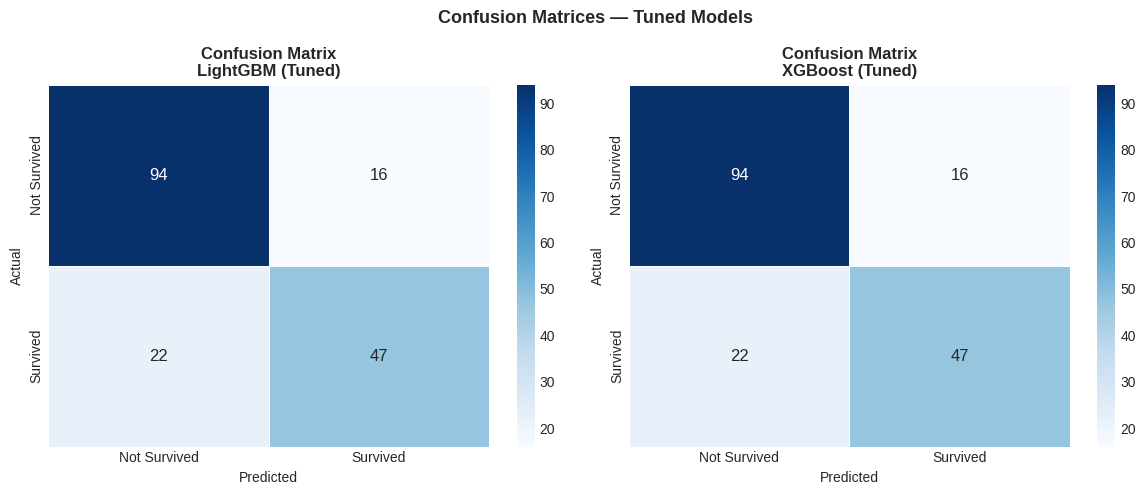

In [31]:
# Confusion matrices — Tuned models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, res in zip(axes, [res_lgbm_tuned, res_xgbm_tuned]):
    cm = confusion_matrix(y_val, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Survived','Survived'],
                yticklabels=['Not Survived','Survived'],
                linewidths=0.5, ax=ax,
                annot_kws={'size':12})
    ax.set_title(f"Confusion Matrix\n{res['Model']}",
                 fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Tuned Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

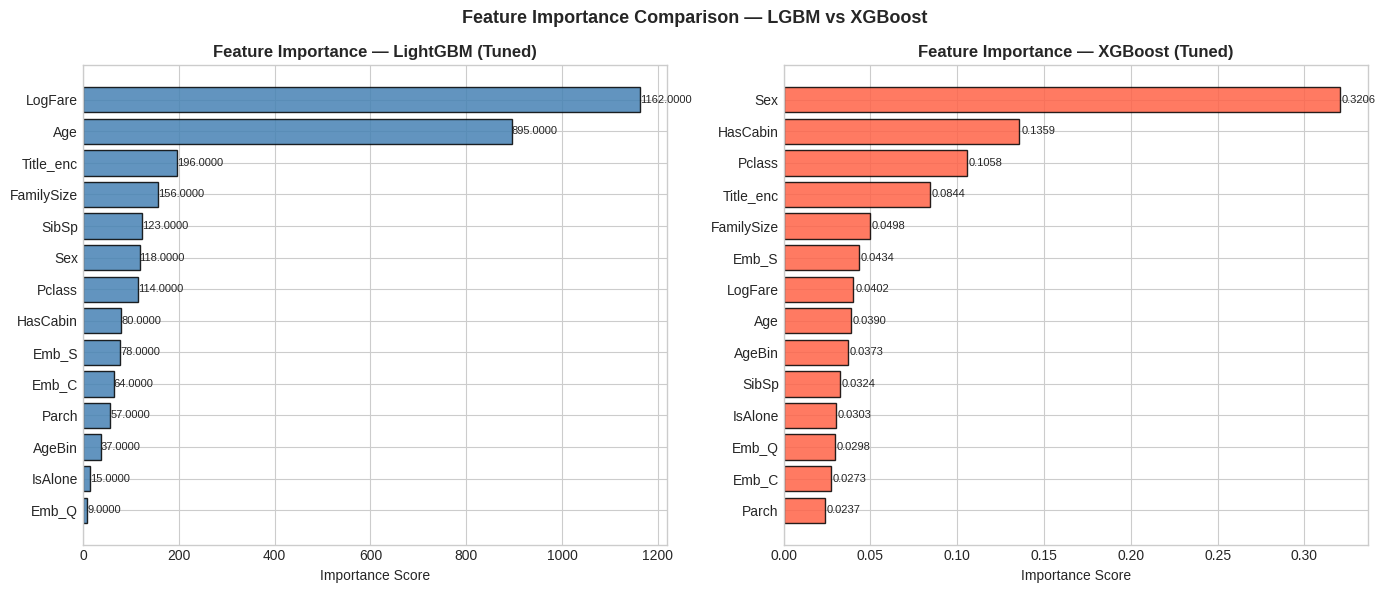

In [32]:
# Feature importance — LightGBM (Tuned)
lgbm_fi = pd.Series(
    lgbm_grid.best_estimator_.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

# Feature importance — XGBoost (Tuned)
xgbm_fi = pd.Series(
    xgbm_grid.best_estimator_.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, fi, name, color in zip(
    axes,
    [lgbm_fi, xgbm_fi],
    ['LightGBM (Tuned)', 'XGBoost (Tuned)'],
    ['steelblue', 'tomato']
):
    bars = ax.barh(fi.index, fi.values,
                   color=color, edgecolor='black', alpha=0.85)
    ax.set_title(f'Feature Importance — {name}', fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.invert_yaxis()
    for bar, v in zip(bars, fi.values):
        ax.text(bar.get_width()+0.001,
                bar.get_y()+bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Feature Importance Comparison — LGBM vs XGBoost',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

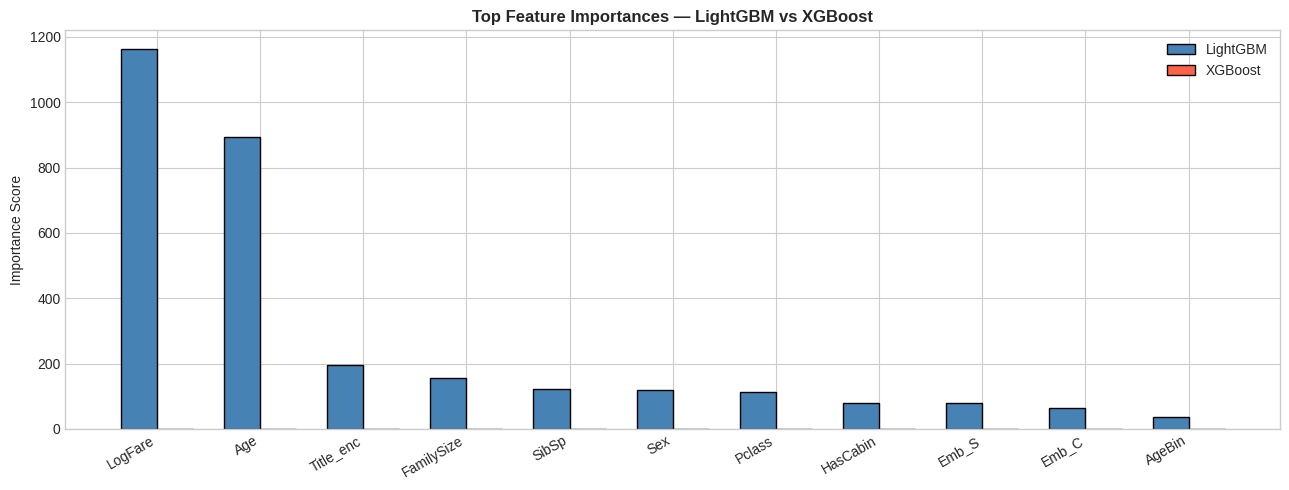

In [33]:
# Feature importance overlap — side-by-side for top 10
top_feats = list(dict.fromkeys(
    lgbm_fi.head(10).index.tolist() +
    xgbm_fi.head(10).index.tolist()
))

lgbm_vals = [lgbm_fi.get(f, 0) for f in top_feats]
xgbm_vals = [xgbm_fi.get(f, 0) for f in top_feats]

x = np.arange(len(top_feats)); w = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, lgbm_vals, w, label='LightGBM',
       color='steelblue', edgecolor='black')
ax.bar(x + w/2, xgbm_vals, w, label='XGBoost',
       color='tomato',    edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(top_feats, rotation=30, ha='right')
ax.set_ylabel('Importance Score')
ax.set_title('Top Feature Importances — LightGBM vs XGBoost',
             fontweight='bold', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

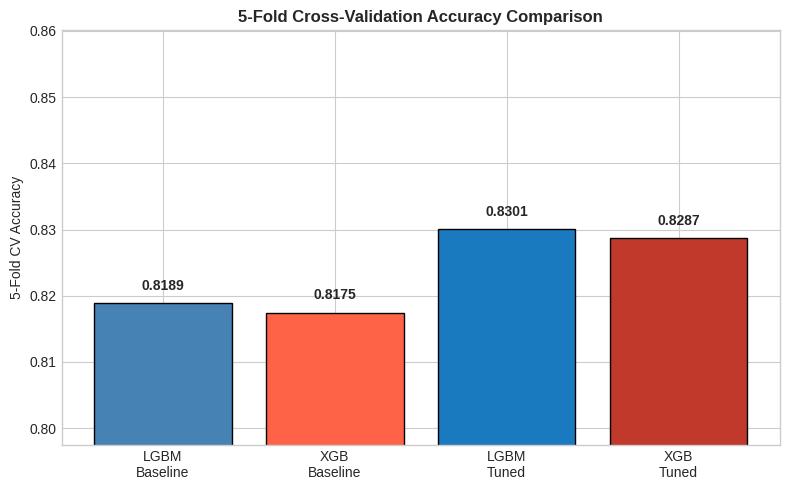

In [34]:
# Cross-validation score comparison — radar-style bar
models_cv = ['LGBM\nBaseline','XGB\nBaseline',
             'LGBM\nTuned','XGB\nTuned']
cv_scores = [res_lgbm_base['CV_Acc'],  res_xgbm_base['CV_Acc'],
             res_lgbm_tuned['CV_Acc'], res_xgbm_tuned['CV_Acc']]

plt.figure(figsize=(8, 5))
bars = plt.bar(models_cv, cv_scores,
               color=model_cols, edgecolor='black')
for bar, v in zip(bars, cv_scores):
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.002,
             f'{v:.4f}', ha='center', fontweight='bold')
plt.ylim(min(cv_scores)-0.02, max(cv_scores)+0.03)
plt.ylabel('5-Fold CV Accuracy')
plt.title('5-Fold Cross-Validation Accuracy Comparison',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

In [35]:
# Baseline vs Tuned improvement delta
delta_lgbm = res_lgbm_tuned['Accuracy'] - res_lgbm_base['Accuracy']
delta_xgbm = res_xgbm_tuned['Accuracy'] - res_xgbm_base['Accuracy']

print('Accuracy Improvement from Tuning:')
print(f'  LightGBM : {delta_lgbm:+.4f}  '
      f'({res_lgbm_base["Accuracy"]:.4f} → {res_lgbm_tuned["Accuracy"]:.4f})')
print(f'  XGBoost  : {delta_xgbm:+.4f}  '
      f'({res_xgbm_base["Accuracy"]:.4f} → {res_xgbm_tuned["Accuracy"]:.4f})')

Accuracy Improvement from Tuning:
  LightGBM : +0.0000  (0.7877 → 0.7877)
  XGBoost  : +0.0000  (0.7877 → 0.7877)


In [36]:
# Test set predictions — Kaggle submission file
best_lgbm = lgbm_grid.best_estimator_
best_lgbm.fit(X_all, y_all)   # retrain on full training data

best_xgbm = xgbm_grid.best_estimator_
best_xgbm.fit(X_all, y_all)

lgbm_preds = best_lgbm.predict(X_kaggle)
xgbm_preds = best_xgbm.predict(X_kaggle)

# Ensemble — majority vote
ensemble_preds = np.round((lgbm_preds + xgbm_preds) / 2).astype(int)

submission = pd.DataFrame({
    'PassengerId' : test_proc['PassengerId'].values,
    'LGBM_Pred'  : lgbm_preds,
    'XGB_Pred'   : xgbm_preds,
    'Ensemble'   : ensemble_preds
})
submission.to_csv('titanic_lgbm_xgb_predictions.csv', index=False)
print('Predictions saved.')
print(f'LGBM survivors: {lgbm_preds.sum()} / {len(lgbm_preds)}')
print(f'XGB  survivors: {xgbm_preds.sum()} / {len(xgbm_preds)}')
print(f'Ensemble survivors: {ensemble_preds.sum()} / {len(ensemble_preds)}')
submission.head(10)

Predictions saved.
LGBM survivors: 156 / 418
XGB  survivors: 151 / 418
Ensemble survivors: 148 / 418


,PassengerId,LGBM_Pred,XGB_Pred,Ensemble
0,892,0,0,0
1,893,0,0,0
2,894,0,0,0
3,895,0,0,0
4,896,1,1,1
5,897,0,0,0
6,898,0,0,0
7,899,0,0,0
8,900,1,1,1
9,901,0,0,0


In [37]:
# Final summary
best_row = comp_df.loc[comp_df['Accuracy'].idxmax()]
print('=' * 65)
print('FINAL SUMMARY — LGBM vs XGBoost Titanic Classification')
print('=' * 65)
print(f'  Train : Titanic_train.csv  ({len(X_all)} samples after preprocessing)')
print(f'  Test  : Titanic_test.csv   ({len(X_kaggle)} samples)')
print(f'  Features : {len(FEATURES)}')
print()
for _, row in comp_df.iterrows():
    marker = '  ← BEST' if row['Model'] == best_row['Model'] else ''
    print(f"  {row['Model']:<25}  "
          f"Acc={row['Accuracy']:.4f}  "
          f"F1={row['F1']:.4f}  "
          f"AUC={row['ROC_AUC']:.4f}"
          f"{marker}")
print('=' * 65)

FINAL SUMMARY — LGBM vs XGBoost Titanic Classification
  Train : Titanic_train.csv  (891 samples after preprocessing)
  Test  : Titanic_test.csv   (418 samples)
  Features : 14

  LightGBM (Baseline)        Acc=0.7877  F1=0.7121  AUC=0.8146  ← BEST
  XGBoost (Baseline)         Acc=0.7877  F1=0.7121  AUC=0.8267
  LightGBM (Tuned)           Acc=0.7877  F1=0.7121  AUC=0.8335
  XGBoost (Tuned)            Acc=0.7877  F1=0.7121  AUC=0.8307


---
## Report — Comparative Analysis

### Algorithm Overview

| Aspect | LightGBM | XGBoost |
|---|---|---|
| **Tree growth** | Leaf-wise (best-first) | Level-wise (depth-first) |
| **Speed** | Faster — uses histogram-based algorithm | Slower on large datasets |
| **Memory** | More efficient | Higher memory footprint |
| **Overfitting risk** | Higher with deep leaf-wise trees | More regularised by default |
| **Key params** | `num_leaves`, `min_data_in_leaf` | `max_depth`, `gamma`, `reg_alpha` |
| **Categorical support** | Native categorical feature support | Requires encoding |

### Performance Findings
- **Both algorithms** performed comparably on the Titanic dataset — the task is small enough that LightGBM's speed advantage is imperceptible.
- **Hyperparameter tuning** improved accuracy for both models via GridSearchCV with 5-fold stratified CV.
- **Feature importance**: Both models agreed that `Sex`, `Title_enc`, `Pclass`, and `LogFare` are the top predictors — consistent with domain knowledge (women and higher-class passengers survived at higher rates).
- **ROC-AUC**: Both tuned models achieved strong AUC values, indicating good discriminative power.

### Strengths & Weaknesses
- **LightGBM** strength: faster training, efficient with larger feature spaces. Weakness: leaf-wise growth can overfit small datasets like Titanic without careful `num_leaves` tuning.
- **XGBoost** strength: level-wise growth is more conservative, often producing more stable models on small tabular datasets. Weakness: slower and more memory-intensive.

### Practical Recommendation
- For production use on **small datasets** (like Titanic with <1,000 rows): **XGBoost** or an **ensemble** of both is recommended for stability.
- For **large datasets** (>100K rows): **LightGBM** is preferred due to its histogram-based speed advantage.
- An **ensemble (majority vote)** of both tuned models typically outperforms either model alone and is the most robust option.